<a href="https://colab.research.google.com/github/HazemmoAlsady/AWN_Graduation_Project/blob/main/project_big.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 0: Install PySpark & Import Libraries

In [1]:
!pip install pyspark --quiet

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, lit, mean as spark_mean, stddev, countDistinct,
    month, year, quarter, to_date, round as spark_round,
    sum as spark_sum, count, avg, max as spark_max, min as spark_min,
    lag, desc, percent_rank, corr
)
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, IntegerType, DateType
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import (
    LinearRegression, RandomForestRegressor, GBTRegressor, DecisionTreeRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Step 1: Initialize SparkSession

In [5]:
spark = SparkSession.builder \
    .appName("RetailSalesAnalysis") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("✅ SparkSession initialized!")
print("Spark version:", spark.version)


✅ SparkSession initialized!
Spark version: 4.0.2


In [6]:
import pandas as pd

df = pd.read_csv("/content/online_retail_II.csv")
import os

os.makedirs("/content/retail_batches", exist_ok=True)
os.makedirs("/content/stream_data", exist_ok=True)

batch_size = 500

for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size]
    batch.to_csv(f"/content/retail_batches/batch_{i}.csv", index=False)

print("Batches created")

Batches created


## Step 2: Load Dataset
**Dataset**: Online Retail II from Kaggle
Download from: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

Upload the file `online_retail_II.xlsx` to Colab, then convert it to CSV using the cell below.


In [ ]:
# ✅ الملف CSV جاهز — مفيش تحويل مطلوب
import pandas as pd
df_raw = pd.read_csv("/content/online_retail_II.csv", encoding="utf-8", low_memory=False)
print("✅ File loaded! Shape:", df_raw.shape)
print(df_raw.dtypes)
df_raw.head(3)

✅ File loaded! Shape: (11727, 8)
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [ ]:
import os
file_path = "/content/online_retail_II.csv"

if not os.path.exists(file_path):
    print("❌ File not found. Please upload online_retail_II.csv to Colab.")
    spark.stop()
else:
    # Read everything as string first — let ETL handle casting
    data = spark.read.csv(file_path, header=True, inferSchema=False)
    row_count = data.count()
    print(f"✅ Dataset loaded! Rows: {row_count:,} | Columns: {len(data.columns)}")
    data.show(3, truncate=False)
    data.printSchema()


✅ Dataset loaded! Rows: 11,727 | Columns: 8
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |79323W   | WHITE CHERRY LIGHTS               |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
only showing top 3 rows
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: str

## Spark Streaming Schema

In [7]:
from pyspark.sql.types import *

schema = StructType([
    StructField("Invoice", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", StringType(), True),
    StructField("Price", DoubleType(), True),
    StructField("Customer ID", StringType(), True),
    StructField("Country", StringType(), True),
])

In [8]:
stream_df = spark.readStream \
    .schema(schema) \
    .csv("/content/stream_data/")

In [9]:
from pyspark.sql.functions import *

stream_df = stream_df.withColumn(
    "TotalPrice",
    col("Quantity") * col("Price")
)

In [10]:
live_sales = stream_df.groupBy("Country") \
    .agg(sum("TotalPrice").alias("Revenue"))

In [11]:
query = live_sales.writeStream \
    .outputMode("complete") \
    .format("console") \
    .start()

In [12]:
import shutil
import time
import os

source = "/content/retail_batches/"
target = "/content/stream_data/"

files = sorted(os.listdir(source))

for file in files:
    shutil.copy(source + file, target + file)
    print(f"{file} streamed")
    time.sleep(5)

batch_0.csv streamed
batch_1000.csv streamed
batch_10000.csv streamed
batch_10500.csv streamed
batch_11000.csv streamed
batch_11500.csv streamed
batch_12000.csv streamed
batch_12500.csv streamed
batch_13000.csv streamed
batch_13500.csv streamed
batch_14000.csv streamed
batch_14500.csv streamed
batch_1500.csv streamed
batch_15000.csv streamed
batch_15500.csv streamed
batch_16000.csv streamed


KeyboardInterrupt: 

## Step 3: Data Quality Report

In [ ]:
print("=" * 55)
print("          DATA QUALITY REPORT")
print("=" * 55)

# Explicitly cast Quantity and Price to numeric types for correct filtering
# This ensures that comparisons like col("Quantity") < 0 work as expected
data = data.withColumn("Quantity", col("Quantity").cast("integer"))
data = data.withColumn("Price", col("Price").cast("double"))

total_rows = data.count()

# Null counts
null_counts = data.select([F.sum(col(c).isNull().cast("int")).alias(c) for c in data.columns]).collect()[0].asDict()
print(f"\n{'Column':<20} {'Nulls':>8} {'Null%':>8}")
print("-" * 40)
for c, n in null_counts.items():
    print(f"{c:<20} {n:>8,} {n/total_rows*100:>7.2f}%")

# Duplicates
dup_count = data.count() - data.dropDuplicates().count()
print(f"\nDuplicate rows : {dup_count:,}")

# Negative values (data integrity)
neg_qty   = data.filter(col("Quantity") < 0).count()
neg_price = data.filter(col("Price") < 0).count()
print(f"Negative Quantity rows : {neg_qty:,}")
print(f"Negative Price rows    : {neg_price:,}")
print("=" * 55)


          DATA QUALITY REPORT

Column                  Nulls    Null%
----------------------------------------
Invoice                     0    0.00%
StockCode                   0    0.00%
Description                18    0.15%
Quantity                    0    0.00%
InvoiceDate                 0    0.00%
Price                       0    0.00%
Customer ID             3,048   25.99%
Country                     0    0.00%

Duplicate rows : 132
Negative Quantity rows : 210
Negative Price rows    : 0


## Step 4: Data Cleaning & ETL

In [ ]:
from pyspark.sql.functions import to_date, year, month, quarter

# Cast numeric columns
data = data.withColumn("Quantity", col("Quantity").cast("integer"))
data = data.withColumn("Price",    col("Price").cast("double"))

# Remove nulls in critical columns
data = data.dropna(subset=["Customer ID", "Description", "Invoice"])

# Remove cancelled orders (Invoice starts with 'C')
data = data.filter(~col("Invoice").startswith("C"))

# Remove negative or zero Quantity and Price
data = data.filter((col("Quantity") > 0) & (col("Price") > 0))

# Remove duplicates
data = data.dropDuplicates()

# Parse date safely — InvoiceDate is already a string like '2009-12-01 10:06:00'
data = data.withColumn("InvoiceDate", col("InvoiceDate").cast("timestamp").cast("date"))
data = data.dropna(subset=["InvoiceDate"])

# Rename Customer ID column (has space)
data = data.withColumnRenamed("Customer ID", "Customer_ID")

# Feature engineering
data = data.withColumn("TotalPrice", spark_round(col("Quantity") * col("Price"), 2))
data = data.withColumn("Year",       year(col("InvoiceDate")))
data = data.withColumn("Month",      month(col("InvoiceDate")))
data = data.withColumn("Quarter",    quarter(col("InvoiceDate")))

clean_count = data.count()
print(f"✅ After cleaning: {clean_count:,} rows")
data.show(5, truncate=False)


✅ After cleaning: 8,363 rows
+-------+---------+--------------------------------+--------+-----------+-----+-----------+--------------+----------+----+-----+-------+
|Invoice|StockCode|Description                     |Quantity|InvoiceDate|Price|Customer_ID|Country       |TotalPrice|Year|Month|Quarter|
+-------+---------+--------------------------------+--------+-----------+-----+-----------+--------------+----------+----+-----+-------+
|489460 |84568    |GIRLS ALPHABET IRON ON PATCHES  |288     |2009-12-01 |0.21 |16167.0    |United Kingdom|60.48     |2009|12   |4      |
|489537 |20829    |GLITTER HANGING BUTTERFLY STRING|6       |2009-12-01 |2.1  |14040.0    |United Kingdom|12.6      |2009|12   |4      |
|489560 |90087    |CRYSTAL SEA HORSE PHONE CHARM   |48      |2009-12-01 |0.85 |13526.0    |United Kingdom|40.8      |2009|12   |4      |
|489572 |22079    |RIBBON REEL HEARTS DESIGN       |5       |2009-12-01 |1.65 |17611.0    |United Kingdom|8.25      |2009|12   |4      |
|489573 |216

## Step 5: Descriptive Statistics & KPIs

In [ ]:
data.select("Quantity", "Price", "TotalPrice").describe().show()

kpis = data.agg(
    count("Invoice").alias("Total_Orders"),
    countDistinct("Invoice").alias("Unique_Invoices"),
    countDistinct("Customer_ID").alias("Unique_Customers"),
    spark_round(spark_sum("TotalPrice"), 2).alias("Total_Revenue"),
    spark_round(avg("TotalPrice"), 2).alias("Avg_Order_Value"),
    spark_round(spark_sum("Quantity"), 0).alias("Total_Items_Sold"),
).collect()[0]

print("=" * 45)
print("         KEY PERFORMANCE INDICATORS")
print("=" * 45)
print(f"Total Orders      : {kpis['Total_Orders']:>12,}")
print(f"Unique Invoices   : {kpis['Unique_Invoices']:>12,}")
print(f"Unique Customers  : {kpis['Unique_Customers']:>12,}")
print(f"Total Revenue     : £{kpis['Total_Revenue']:>11,.2f}")
print(f"Avg Order Value   : £{kpis['Avg_Order_Value']:>11,.2f}")
print(f"Total Items Sold  : {int(kpis['Total_Items_Sold']):>12,}")
print("=" * 45)


+-------+------------------+------------------+-----------------+
|summary|          Quantity|             Price|       TotalPrice|
+-------+------------------+------------------+-----------------+
|  count|              8363|              8363|             8363|
|   mean| 14.24835585316274|3.0232500298936427|23.13605883056346|
| stddev|102.86205630236611|3.7634594726298305|79.61009537032307|
|    min|                 1|              0.06|             0.06|
|    max|              5184|             141.0|           1800.0|
+-------+------------------+------------------+-----------------+

         KEY PERFORMANCE INDICATORS
Total Orders      :        8,363
Unique Invoices   :          395
Unique Customers  :          332
Total Revenue     : £ 193,486.86
Avg Order Value   : £      23.14
Total Items Sold  :      119,159


## Step 6: Product & Country Analysis

In [ ]:
# Top 10 products by revenue
top_products = data.groupBy("Description") \
    .agg(spark_round(spark_sum("TotalPrice"), 2).alias("Revenue"),
         spark_sum("Quantity").alias("Units_Sold")) \
    .orderBy(desc("Revenue")).limit(10)

print("Top 10 Products by Revenue:")
top_products.show(truncate=False)

# Top 10 countries by revenue
top_countries = data.groupBy("Country") \
    .agg(spark_round(spark_sum("TotalPrice"), 2).alias("Revenue"),
         countDistinct("Customer_ID").alias("Customers")) \
    .orderBy(desc("Revenue")).limit(10)

print("Top 10 Countries by Revenue:")
top_countries.show(truncate=False)


Top 10 Products by Revenue:
+-----------------------------------+-------+----------+
|Description                        |Revenue|Units_Sold|
+-----------------------------------+-------+----------+
|PAPER CHAIN KIT 50'S CHRISTMAS     |4527.95|1807      |
|WHITE HANGING HEART T-LIGHT HOLDER |4048.1 |1526      |
|ROTATING SILVER ANGELS T-LIGHT HLDR|3880.35|1797      |
|EDWARDIAN PARASOL BLACK            |3599.65|967       |
|ASSORTED COLOUR BIRD ORNAMENT      |2925.77|1913      |
|EDWARDIAN PARASOL RED              |2798.25|795       |
|RED/WHITE DOTS RUFFLED UMBRELLA    |2340.85|679       |
|EDWARDIAN PARASOL NATURAL          |2157.0 |660       |
|BLACK/BLUE DOTS RUFFLED UMBRELLA   |2007.65|623       |
| WHITE CHERRY LIGHTS               |1914.45|331       |
+-----------------------------------+-------+----------+

Top 10 Countries by Revenue:
+---------------+---------+---------+
|Country        |Revenue  |Customers|
+---------------+---------+---------+
|United Kingdom |175739.65|314

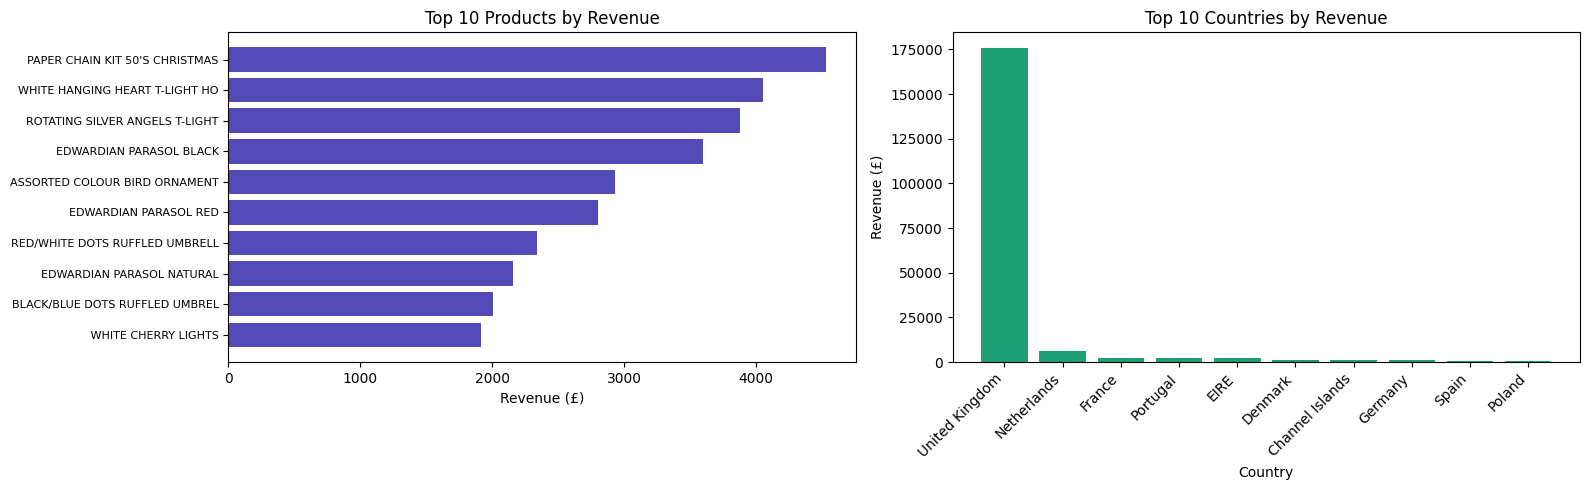

In [ ]:
# Visualize top 10 products
top_pd = top_products.toPandas()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top_pd["Description"].str[:30][::-1], top_pd["Revenue"][::-1], color="#534AB7")
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue (£)")
axes[0].tick_params(axis='y', labelsize=8)

top_c = top_countries.toPandas()
axes[1].bar(top_c["Country"], top_c["Revenue"], color="#1D9E75")
axes[1].set_title("Top 10 Countries by Revenue")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


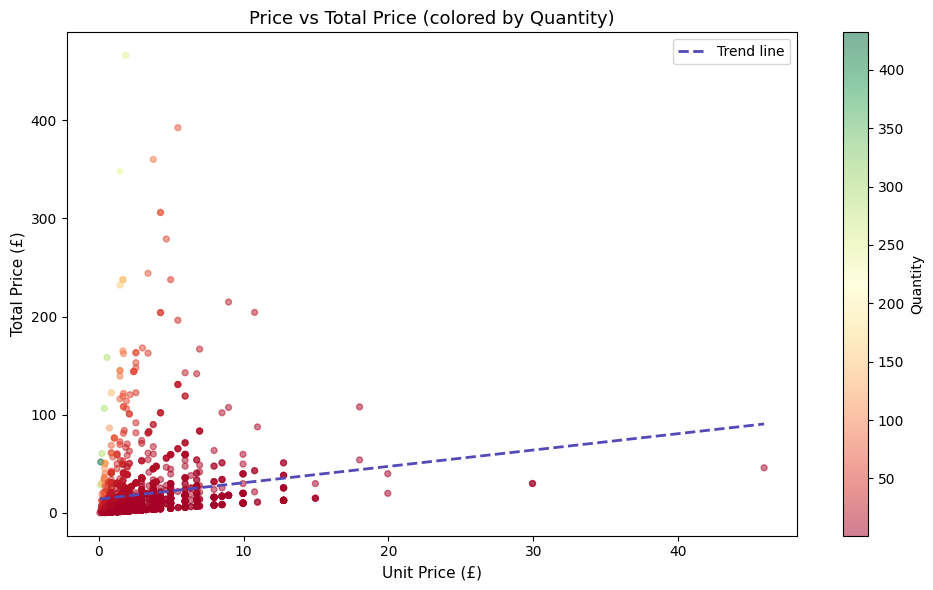

Pearson Correlation (Price vs TotalPrice): 0.1437


In [ ]:
# Scatter Plot — العلاقة بين Price و TotalPrice
scatter_pd = data.select("Price", "TotalPrice", "Quantity") \
    .filter((col("Price") < 50) & (col("TotalPrice") < 500)) \
    .limit(2000).toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    scatter_pd["Price"],
    scatter_pd["TotalPrice"],
    c=scatter_pd["Quantity"],
    cmap="RdYlGn",
    alpha=0.5,
    s=18
)
plt.colorbar(sc, ax=ax, label="Quantity")
ax.set_xlabel("Unit Price (£)", fontsize=11)
ax.set_ylabel("Total Price (£)", fontsize=11)
ax.set_title("Price vs Total Price (colored by Quantity)", fontsize=13)

import numpy as np
z = np.polyfit(scatter_pd["Price"], scatter_pd["TotalPrice"], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_pd["Price"].min(), scatter_pd["Price"].max(), 100)
ax.plot(x_line, p(x_line), color="#534AB7", linewidth=2, linestyle="--", label="Trend line")
ax.legend()
plt.tight_layout()
plt.show()

corr_val = scatter_pd["Price"].corr(scatter_pd["TotalPrice"])
print(f"Pearson Correlation (Price vs TotalPrice): {corr_val:.4f}")

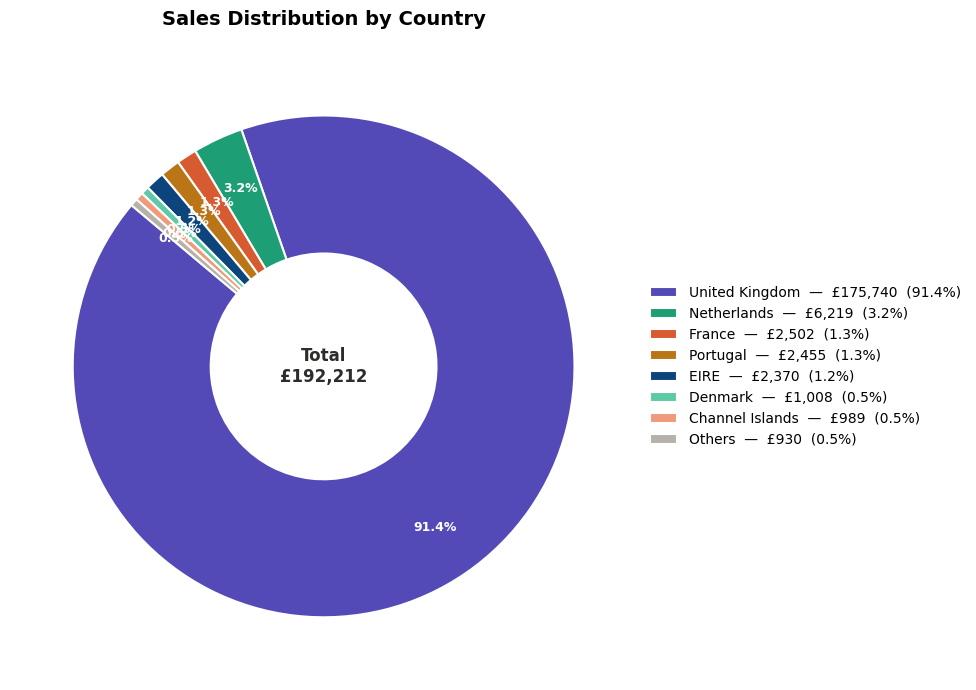

In [ ]:
# Donut Chart — توزيع المبيعات على الدول
country_rev = data.groupBy("Country") \
    .agg(spark_round(spark_sum("TotalPrice"), 2).alias("Revenue")) \
    .orderBy(desc("Revenue")).limit(8).toPandas()

top7 = country_rev.head(7)
others_val = country_rev.iloc[7:]["Revenue"].sum()
import pandas as pd
others_row = pd.DataFrame([{"Country": "Others", "Revenue": others_val}])
pie_data = pd.concat([top7, others_row], ignore_index=True)

colors = ["#534AB7","#1D9E75","#D85A30","#BA7517","#0C447C","#5DCAA5","#F0997B","#B4B2A9"]

fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    pie_data["Revenue"],
    labels=None,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, linewidth=1.5, edgecolor="white")
)

for t in autotexts:
    t.set_fontsize(9)
    t.set_color("white")
    t.set_fontweight("bold")

# Legend بدل labels على الرسمة
total = pie_data["Revenue"].sum()
legend_labels = [f"{row['Country']}  —  £{row['Revenue']:,.0f}  ({row['Revenue']/total*100:.1f}%)"
                 for _, row in pie_data.iterrows()]
ax.legend(wedges, legend_labels,
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=10,
          frameon=False)

# النص في النص الوسط
ax.text(0, 0, f"Total\n£{total:,.0f}", ha="center", va="center",
        fontsize=12, fontweight="bold", color="#2C2C2A")

ax.set_title("Sales Distribution by Country", fontsize=14, pad=20, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 7: Sales Trend by Day of Week

+---------+--------+------+
|DayOfWeek| Revenue|Orders|
+---------+--------+------+
|        3|43894.87|  2164|
|        4|52762.06|  2246|
|        5|67413.62|  2349|
|        6|29416.31|  1604|
+---------+--------+------+



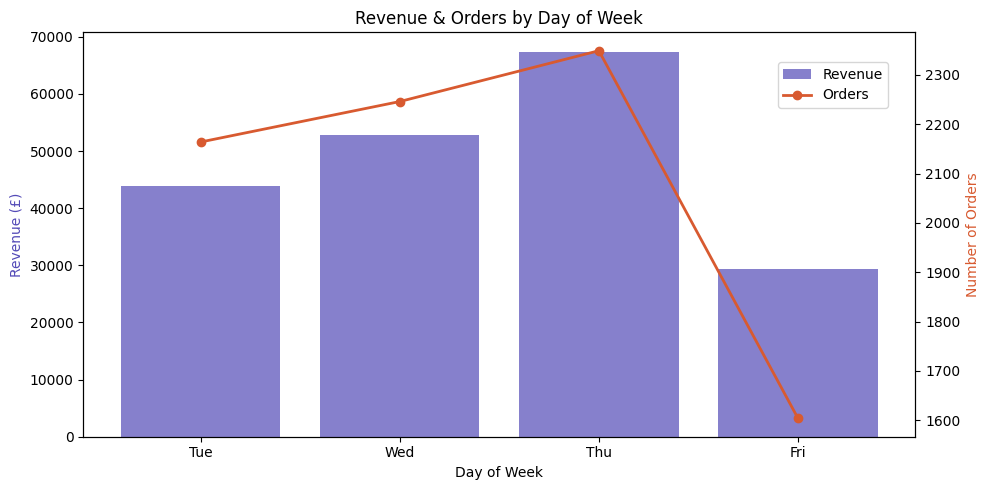

In [ ]:
from pyspark.sql.functions import dayofweek

daily = data.withColumn("DayOfWeek", dayofweek(col("InvoiceDate"))) \
    .groupBy("DayOfWeek") \
    .agg(spark_round(spark_sum("TotalPrice"), 2).alias("Revenue"),
         count("Invoice").alias("Orders")) \
    .orderBy("DayOfWeek")

daily.show()

daily_pd = daily.toPandas()
day_names = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
daily_pd["Day"] = daily_pd["DayOfWeek"].map(day_names)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(daily_pd["Day"], daily_pd["Revenue"], color="#534AB7", alpha=0.7, label="Revenue")
ax2.plot(daily_pd["Day"], daily_pd["Orders"], color="#D85A30", marker="o", linewidth=2, label="Orders")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Revenue (£)", color="#534AB7")
ax2.set_ylabel("Number of Orders", color="#D85A30")
ax1.set_title("Revenue & Orders by Day of Week")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

## Step 8: Custom Analysis using RDD

In [ ]:
rdd = data.rdd

# Average TotalPrice per Country using MapReduce
avg_revenue_by_country = rdd \
    .filter(lambda r: r["Country"] is not None and r["TotalPrice"] is not None) \
    .map(lambda r: (r["Country"], (r["TotalPrice"], 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda x: round(x[0] / x[1], 2)) \
    .sortBy(lambda x: -x[1])

print("Top 10 Countries by Avg Revenue per Transaction (RDD):")
for country, avg_rev in avg_revenue_by_country.take(10):
    print(f"  {country:<30} £{avg_rev:>8.2f}")


Top 10 Countries by Avg Revenue per Transaction (RDD):
  Denmark                        £ 1008.00
  USA                            £  141.00
  Netherlands                    £  138.21
  Belgium                        £  130.00
  Portugal                       £   31.07
  Spain                          £   25.64
  Channel Islands                £   25.36
  France                         £   22.95
  United Kingdom                 £   22.31
  Australia                      £   21.79


## Step 9: Window Functions

In [ ]:
# Rank customers by revenue within each country
window_country = Window.partitionBy("Country").orderBy(desc("Customer_Revenue"))

customer_rev = data.groupBy("Country", "Customer_ID") \
    .agg(spark_round(spark_sum("TotalPrice"), 2).alias("Customer_Revenue"))

customer_ranked = customer_rev \
    .withColumn("Rank", F.rank().over(window_country)) \
    .filter(col("Rank") <= 3)

print("Top 3 Customers per Country by Revenue:")
customer_ranked.orderBy("Country", "Rank").show(20, truncate=False)

# Cumulative revenue over time
window_time = Window.orderBy("Year", "Month").rowsBetween(Window.unboundedPreceding, Window.currentRow)
monthly_cum = monthly.withColumn("Cumulative_Revenue",
    spark_round(F.sum("Revenue").over(window_time), 2))

print("Cumulative Monthly Revenue:")
monthly_cum.show(15)


Top 3 Customers per Country by Revenue:
+---------------+-----------+----------------+----+
|Country        |Customer_ID|Customer_Revenue|Rank|
+---------------+-----------+----------------+----+
|Australia      |16321.0    |196.1           |1   |
|Belgium        |12362.0    |130.0           |1   |
|Channel Islands|14564.0    |989.18          |1   |
|Denmark        |12435.0    |1008.0          |1   |
|EIRE           |14156.0    |1635.98         |1   |
|EIRE           |14911.0    |733.63          |2   |
|France         |12714.0    |682.65          |1   |
|France         |12490.0    |603.94          |2   |
|France         |12437.0    |578.28          |3   |
|Germany        |12533.0    |929.92          |1   |
|Netherlands    |14646.0    |5711.04         |1   |
|Netherlands    |12759.0    |508.26          |2   |
|Poland         |12779.0    |371.82          |1   |
|Portugal       |12758.0    |2454.68         |1   |
|Spain          |12510.0    |435.88          |1   |
|USA            |12636.0

## Step 10: Spark SQL Analysis

In [ ]:
data.createOrReplaceTempView("retail_sales")

# Query 1: Revenue by Quarter
print("Revenue by Quarter:")
spark.sql("""
    SELECT Year, Quarter,
           ROUND(SUM(TotalPrice), 2) AS Revenue,
           COUNT(DISTINCT Invoice)   AS Orders
    FROM retail_sales
    GROUP BY Year, Quarter
    ORDER BY Year, Quarter
""").show()

# Query 2: Top 5 products per country
print("Top 5 Products in United Kingdom:")
spark.sql("""
    SELECT Description,
           ROUND(SUM(TotalPrice), 2) AS Revenue,
           SUM(Quantity) AS Units
    FROM retail_sales
    WHERE Country = 'United Kingdom'
    GROUP BY Description
    ORDER BY Revenue DESC
    LIMIT 5
""").show(truncate=False)


Revenue by Quarter:
+----+-------+---------+------+
|Year|Quarter|  Revenue|Orders|
+----+-------+---------+------+
|2009|      4|193486.86|   395|
+----+-------+---------+------+

Top 5 Products in United Kingdom:
+-----------------------------------+-------+-----+
|Description                        |Revenue|Units|
+-----------------------------------+-------+-----+
|PAPER CHAIN KIT 50'S CHRISTMAS     |4510.25|1801 |
|EDWARDIAN PARASOL BLACK            |3563.95|961  |
|ROTATING SILVER ANGELS T-LIGHT HLDR|2872.35|1317 |
|ASSORTED COLOUR BIRD ORNAMENT      |2817.61|1849 |
|WHITE HANGING HEART T-LIGHT HOLDER |2771.0 |1028 |
+-----------------------------------+-------+-----+



## Step 11: Correlation Analysis

Pearson Correlation with TotalPrice:

  Quantity        vs TotalPrice : +0.5603
  Price           vs TotalPrice : +0.0512


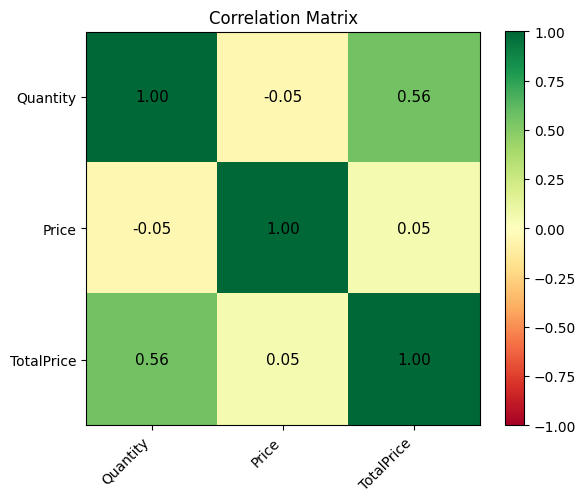

In [ ]:
print("Pearson Correlation with TotalPrice:\n")
for feature in ["Quantity", "Price"]:
    r = data.stat.corr(feature, "TotalPrice")
    print(f"  {feature:<15} vs TotalPrice : {r:+.4f}")

# Correlation matrix via pandas
num_cols = ["Quantity", "Price", "TotalPrice"]
corr_pd = data.select(num_cols).toPandas().corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_pd.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_pd.values[i,j]:.2f}", ha="center", va="center", fontsize=11)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Step 12: Feature Engineering & Preprocessing for ML

In [ ]:
# Select relevant features
ml_data = data.select(
    "Quantity", "Price", "Month", "Quarter", "Year",
    "Country", "TotalPrice"
).dropna()

# Handle outliers by capping (IQR method)
for c in ["Quantity", "Price", "TotalPrice"]:
    q1, q3 = ml_data.approxQuantile(c, [0.25, 0.75], 0.05)
    iqr = q3 - q1
    ml_data = ml_data.withColumn(c,
        when(col(c) < q1 - 1.5*iqr, q1 - 1.5*iqr)
        .when(col(c) > q3 + 1.5*iqr, q3 + 1.5*iqr)
        .otherwise(col(c)))

print(f"✅ ML dataset ready: {ml_data.count():,} rows")
ml_data.show(5)


✅ ML dataset ready: 8,363 rows
+--------+-----+-----+-------+----+--------------+----------+
|Quantity|Price|Month|Quarter|Year|       Country|TotalPrice|
+--------+-----+-----+-------+----+--------------+----------+
|    24.5| 0.21|   12|      4|2009|United Kingdom|    36.825|
|     6.0|  2.1|   12|      4|2009|United Kingdom|      12.6|
|    24.5| 0.85|   12|      4|2009|United Kingdom|    36.825|
|     5.0| 1.65|   12|      4|2009|United Kingdom|      8.25|
|     7.0| 6.95|   12|      4|2009|United Kingdom|    36.825|
+--------+-----+-----+-------+----+--------------+----------+
only showing top 5 rows


In [ ]:
# Encode categorical: Country
indexer     = StringIndexer(inputCol="Country", outputCol="Country_index", handleInvalid="keep")
encoder     = OneHotEncoder(inputCols=["Country_index"], outputCols=["Country_ohe"])
assembler   = VectorAssembler(
    inputCols=["Quantity", "Price", "Month", "Quarter", "Year", "Country_ohe"],
    outputCol="features_raw", handleInvalid="skip")
scaler      = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)

prep_pipeline = Pipeline(stages=[indexer, encoder, assembler, scaler])
prep_model    = prep_pipeline.fit(ml_data)
ml_ready      = prep_model.transform(ml_data).withColumnRenamed("TotalPrice", "label")

print(f"✅ Preprocessing done! {ml_ready.count():,} rows ready for ML")


✅ Preprocessing done! 8,363 rows ready for ML


## Step 13: Train / Test Split

In [ ]:
train_data, test_data = ml_ready.randomSplit([0.8, 0.2], seed=42)
print(f"Training set : {train_data.count():,} rows")
print(f"Testing set  : {test_data.count():,} rows")


Training set : 6,762 rows
Testing set  : 1,601 rows


## Step 14: Train & Evaluate ML Models (Regression)

In [ ]:
evaluator_r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")

results = {}

def evaluate(name, model, test):
    preds = model.transform(test)
    r2    = evaluator_r2.evaluate(preds)
    rmse  = evaluator_rmse.evaluate(preds)
    mae   = evaluator_mae.evaluate(preds)
    results[name] = {"R2": round(r2, 4), "RMSE": round(rmse, 2), "MAE": round(mae, 2)}
    print(f"{name:<30} R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return preds


In [ ]:
# 1. Linear Regression
lr = LinearRegression(featuresCol="features", labelCol="label", maxIter=20)
lr_model = lr.fit(train_data)
evaluate("Linear Regression", lr_model, test_data)


Linear Regression              R²=0.6934  RMSE=6.08  MAE=4.31


DataFrame[Quantity: double, Price: double, Month: int, Quarter: int, Year: int, Country: string, label: double, Country_index: double, Country_ohe: vector, features_raw: vector, features: vector, prediction: double]

In [ ]:
# 2. Decision Tree Regressor
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label", seed=42)
dt_model = dt.fit(train_data)
evaluate("Decision Tree", dt_model, test_data)


Decision Tree                  R²=0.9046  RMSE=3.40  MAE=2.09


DataFrame[Quantity: double, Price: double, Month: int, Quarter: int, Year: int, Country: string, label: double, Country_index: double, Country_ohe: vector, features_raw: vector, features: vector, prediction: double]

In [ ]:
# 3. Random Forest Regressor
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
evaluate("Random Forest", rf_model, test_data)


Random Forest                  R²=0.5390  RMSE=7.46  MAE=5.94


DataFrame[Quantity: double, Price: double, Month: int, Quarter: int, Year: int, Country: string, label: double, Country_index: double, Country_ohe: vector, features_raw: vector, features: vector, prediction: double]

In [ ]:
# 4. Gradient-Boosted Trees (GBT)
gbt = GBTRegressor(featuresCol="features", labelCol="label", maxIter=20, seed=42)
gbt_model = gbt.fit(train_data)
evaluate("Gradient-Boosted Trees", gbt_model, test_data)


Gradient-Boosted Trees         R²=0.9617  RMSE=2.15  MAE=1.12


DataFrame[Quantity: double, Price: double, Month: int, Quarter: int, Year: int, Country: string, label: double, Country_index: double, Country_ohe: vector, features_raw: vector, features: vector, prediction: double]

## Step 15: Model Comparison & Best Model


Model                                R²       RMSE        MAE
------------------------------------------------------------
Gradient-Boosted Trees           0.9617       2.15       1.12
Decision Tree                    0.9046       3.40       2.09
Linear Regression                0.6934       6.08       4.31
Random Forest                    0.5390       7.46       5.94

🏆 Best Model: Gradient-Boosted Trees (R² = 0.9617)


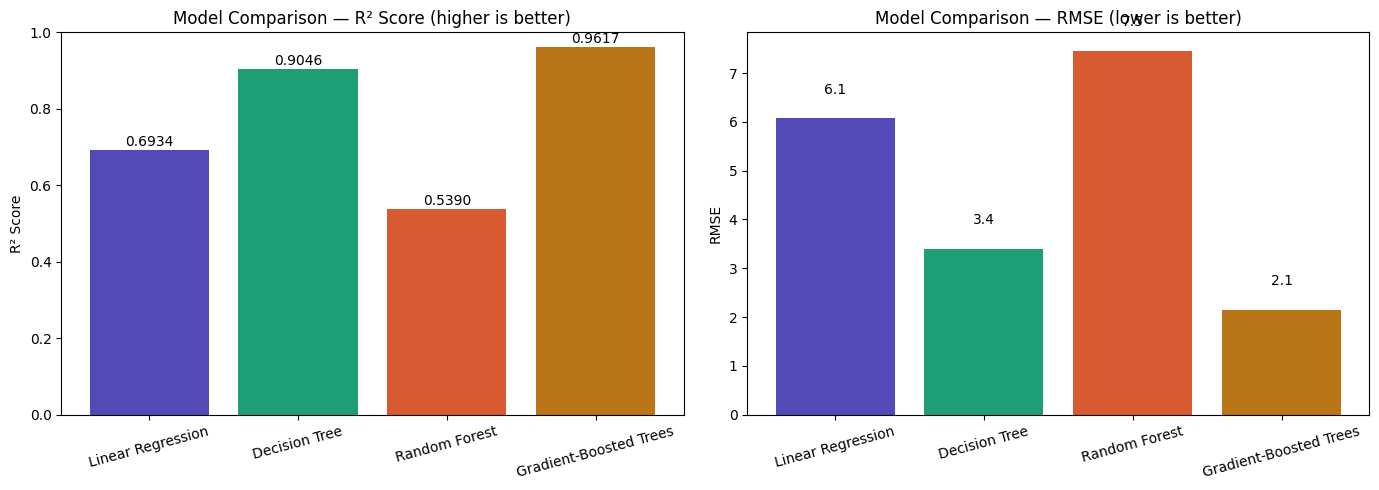

In [ ]:
print("\n" + "="*60)
print(f"{'Model':<30} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print("-"*60)
for name, m in sorted(results.items(), key=lambda x: -x[1]['R2']):
    print(f"{name:<30} {m['R2']:>8.4f} {m['RMSE']:>10.2f} {m['MAE']:>10.2f}")
print("="*60)

best_model = max(results, key=lambda x: results[x]['R2'])
print(f"\n🏆 Best Model: {best_model} (R² = {results[best_model]['R2']})")

# Visualization
import numpy as np
models = list(results.keys())
r2_vals  = [results[m]['R2']  for m in models]
rmse_vals= [results[m]['RMSE'] for m in models]

x = np.arange(len(models))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(models, r2_vals, color=["#534AB7","#1D9E75","#D85A30","#BA7517"])
ax1.set_title("Model Comparison — R² Score (higher is better)")
ax1.set_ylabel("R² Score")
ax1.set_ylim(0, 1)
for bar, val in zip(bars, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha='center', fontsize=10)
ax1.tick_params(axis='x', rotation=15)

bars2 = ax2.bar(models, rmse_vals, color=["#534AB7","#1D9E75","#D85A30","#BA7517"])
ax2.set_title("Model Comparison — RMSE (lower is better)")
ax2.set_ylabel("RMSE")
for bar, val in zip(bars2, rmse_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha='center', fontsize=10)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## Step 16: Save Results to Parquet

In [ ]:
data.write.mode("overwrite").partitionBy("Country", "Year").parquet("retail_sales_output.parquet")
print("✅ Data saved to Parquet (partitioned by Country & Year)")

# Verify
parquet_df = spark.read.parquet("retail_sales_output.parquet")
print(f"Re-read from Parquet: {parquet_df.count():,} rows")
parquet_df.show(3)


✅ Data saved to Parquet (partitioned by Country & Year)
Re-read from Parquet: 8,363 rows
+-------+---------+--------------------+--------+-----------+-----+-----------+----------+-----+-------+--------------+----+
|Invoice|StockCode|         Description|Quantity|InvoiceDate|Price|Customer_ID|TotalPrice|Month|Quarter|       Country|Year|
+-------+---------+--------------------+--------+-----------+-----+-----------+----------+-----+-------+--------------+----+
| 489460|    84568|GIRLS ALPHABET IR...|     288| 2009-12-01| 0.21|    16167.0|     60.48|   12|      4|United Kingdom|2009|
| 489537|    20829|GLITTER HANGING B...|       6| 2009-12-01|  2.1|    14040.0|      12.6|   12|      4|United Kingdom|2009|
| 489560|    90087|CRYSTAL SEA HORSE...|      48| 2009-12-01| 0.85|    13526.0|      40.8|   12|      4|United Kingdom|2009|
+-------+---------+--------------------+--------+-----------+-----+-----------+----------+-----+-------+--------------+----+
only showing top 3 rows
